# Phase On the Fly
### General Story:
We want to change hardware such that we can get phase or phase difference from the adcs in tProc so it can be changed in fewer cycles. Working with tProc2 for consistency of future work

#### Code to make sure everything loads from git

In [1]:
#this block is for running a command on the RFsoC assuming you are 
#running one of the jupyter notebooks on the device but from a separate computer/visual studio code:
import os
dir = os.getcwd()
print(dir)
print(os.listdir())
# print(os.getcwd())
# os.system("pip install gitpython")

/home/xilinx/jupyter_notebooks
['qick', 'user_implementation', 'getting_started', 'common', 'amo_qick', '.ipynb_checkpoints', 'Welcome to Pynq.ipynb']


In [2]:
#this will pull from the github to make sure you have the most current updates

import git  # pip install gitpython
print(os.listdir())
if 'amo_qick' in os.listdir():
        print("getting into fork")
        os.chdir('amo_qick')
dir = os.getcwd()
print(dir)
g = git.cmd.Git(dir)
g.pull()


['qick', 'user_implementation', 'getting_started', 'common', 'amo_qick', '.ipynb_checkpoints', 'Welcome to Pynq.ipynb']
getting into fork
/home/xilinx/jupyter_notebooks/amo_qick


'Already up to date.'

#### Make sure hardware is recognized

In [3]:
from qick import *
from qick.asm_v2 import *
%matplotlib inline
import matplotlib.pyplot as plt

#This line is to sync to an external clock which needs to be 10 Mhz
#this line currently loads tproc1 firmware and is just to make sure everything is loaded properly
#soc = QickSoc(external_clk=True)

dir = os.getcwd()
print(dir)
#this line downloads the new hardware (just make sure thats what you want)
#soc = QickSoc()
#soc = QickSoc(bitfile =f'{dir}/tests/d_1.bit', download=True)
#as of Jan 2026: 
#rfsoc_board = most recently published bit, 
# ADC_0 = Self built file that connects adc port 0 to tproc 1
# d_1 = self built that puts a cordic loop on adc port 0 for phase analysis (doesnt work rn)
soc = QickSoc(bitfile =f'{dir}/tests/rf_board_firmware/d_1.bit', download=True)
soccfg = soc
print(soccfg)


/home/xilinx/jupyter_notebooks/amo_qick
RFSoC PLLs are not locked, configuring reference clock chips (this is normal after power cycle)
LMK04828 clock reference = 245.760 MHz, LMX2594 clock synth = 491.520 MHz
QICK running on ZCU216, software version 0.2.388

Firmware configuration (built Fri Apr  3 16:28:09 2026):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc core clock, tProc timing clock, DAC tile 1, DAC tile 2, DAC tile 3], [DAC tile 0], [ADC tile 1, ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 65536 complex samples (6.838 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 0 is 0_228 on JHC1, or QICK box DAC port 0
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 1 is 1_228 on JHC2, or QICK box DAC port 1
	2:	axis_signal_

# So much Debug for DMA, skip all of this

In [4]:
# list blocks to inspect and print their params
blocks = ['axis_avg_buffer_10','cordic_0','axis_dwidth_converter_0','axi_dma_avg']
for b in blocks:
    print('---', b, 'type=', soc.metadata.mod2type(b))
    params = soc.metadata.modinfo.get(b, {}).get('params', {})
    if not params:
        print('  (no params in modinfo)')
    for k,v in params.items():
        print(' ', k, '=', v)
    print()

--- axis_avg_buffer_10 type= axis_avg_buffer
  N_AVG = 13
  N_BUF = 12
  B = 16
  Component_Name = d_1_axis_avg_buffer_10_0
  EDK_IPTYPE = PERIPHERAL
  C_BASEADDR = 0x400370000
  C_HIGHADDR = 0x40037FFFF



KeyError: 'cordic_0'

In [ ]:
print(soc.metadata.trace_forward('axis_avg_buffer_10','m0_axis', ['cordic','axis_dwidth_converter','axi_dma']))
for b in ['axis_avg_buffer_10','cordic_0','axis_dwidth_converter_0','axi_dma_avg']:
    print('---', b, soc.metadata.mod2type(b))
    params = soc.metadata.modinfo.get(b, {}).get('params', {})
    for k in sorted(params):
        if 'WIDTH' in k or 'TKEEP' in k or 'TLAST' in k or 'TDATA' in k or 'TUSER' in k:
            print(' ', k, '=', params[k])
    # show whether this block exposes TLAST/TREADY nets
    for p in ['M_AXIS','S_AXIS','M_AXIS_DOUT','m_axis','m0_axis','M0_AXIS']:
        full = b + '/' + p
        pin = soc.metadata.busparser.pins.get(full)
        if pin:
            print('  pin', p, '->', pin)
for net in soc.metadata.busparser.nets.values():
    for pname in net:
        if any(x in pname.lower() for x in ['tlast','tready','tkeep','tvalid']):
            print(pname)

In [ ]:
# Diagnostic cell: Check what's actually connected to axis_avg_buffer_10
print("=== Checking axis_avg_buffer_10 connections ===")
print("\nLooking for port connections from axis_avg_buffer_10:")

# Check all possible output port names
possible_ports = ['M_AXIS', 'm_axis', 'M0_AXIS', 'm0_axis', 'AXIS_OUT', 'axis_out']
for port in possible_ports:
    fullport = 'axis_avg_buffer_10/' + port
    netname = soc.metadata.busparser.pins.get(fullport)
    print(f"  {fullport}: {netname}")

print("\n=== Checking metadata about axis_avg_buffer_10 ===")
print("Type:", soc.metadata.mod2type('axis_avg_buffer_10'))
params = soc.metadata.modinfo.get('axis_avg_buffer_10', {}).get('params', {})
print("Params:", list(params.keys()) if params else "(none)")

print("\n=== All blocks containing 'cordic' ===")
all_blocks = soc.metadata.modinfo.keys()
cordic_blocks = [b for b in all_blocks if 'cordic' in b.lower()]
print("Found:", cordic_blocks)

print("\n=== All blocks containing 'dwidth' ===")
dwidth_blocks = [b for b in all_blocks if 'dwidth' in b.lower()]
print("Found:", dwidth_blocks)

print("\n=== All available blocks ===")
print("Total blocks:", len(all_blocks))
print("Block list:", sorted(all_blocks))

In [ ]:
# Simpler diagnostic: Check the actual port connections
print("Port at axis_avg_buffer_10/m0_axis:", soc.metadata.busparser.pins.get('axis_avg_buffer_10/m0_axis'))
print("Port at axis_avg_buffer_10/M_AXIS:", soc.metadata.busparser.pins.get('axis_avg_buffer_10/M_AXIS'))

cordic_blocks = [b for b in soc.metadata.modinfo.keys() if 'cordic' in b.lower()]
dwidth_blocks = [b for b in soc.metadata.modinfo.keys() if 'dwidth' in b.lower()]
print("\nCORDIC blocks found:", cordic_blocks)
print("DWIDTH_CONVERTER blocks found:", dwidth_blocks)
print("\nIf these lists are empty, the blocks were not synthesized into your design.")

In [ ]:
# Trace what's connected to the m0_axis net
print("Tracing the net 'axis_avg_buffer_10_m0_axis':")
net = 'axis_avg_buffer_10_m0_axis'
if net in soc.metadata.busparser.nets:
    print("  Connected ports:", soc.metadata.busparser.nets[net])
else:
    print("  Net not found in nets dict")

# Now try the trace_bus result manually
trace_result = soc.metadata.trace_bus('axis_avg_buffer_10', 'm0_axis')
print("\nTrace result from m0_axis:", trace_result)

if trace_result:
    next_block, next_port = trace_result[0]
    print(f"Next block: {next_block}, port: {next_port}")
    print(f"Block type: {soc.metadata.mod2type(next_block)}")

In [ ]:
# Check CORDIC output ports
print("CORDIC outputs - checking what ports exist and what they connect to:")
cordic_ports = ['M_AXIS_DOUT', 'M_AXIS_PHASE', 'M_AXIS']
for port in cordic_ports:
    fullport = f'cordic_0/{port}'
    netname = soc.metadata.busparser.pins.get(fullport)
    print(f"  {fullport}: {netname}")
    if netname and netname != '__NOC__':
        connected = soc.metadata.busparser.nets.get(netname, [])
        print(f"    -> Connected to: {connected}")

print("\n=== Trying to trace forward from cordic_1 ===")
try:
    trace_result = soc.metadata.trace_bus('cordic_0', 'M_AXIS_DOUT')
    print(f"Trace from M_AXIS_DOUT: {trace_result}")
except Exception as e:
    print(f"Error: {e}")

In [ ]:
# Check axis_dwidth_converter_1 output
print("axis_dwidth_converter_0 outputs:")
for port in ['M_AXIS', 'M_AXIS_DOUT']:
    fullport = f'axis_dwidth_converter_0/{port}'
    netname = soc.metadata.busparser.pins.get(fullport)
    print(f"  {fullport}: {netname}")
    if netname and netname != '__NOC__':
        connected = soc.metadata.busparser.nets.get(netname, [])
        print(f"    -> Connected to: {connected}")

print("\n=== Full chain ===")
print("axis_avg_buffer_10 (m0_axis) → cordic_0 → axis_dwidth_converter_1 → ?")

print("\n=== Now try the original trace_forward ===")
try:
    result = soc.metadata.trace_forward('axis_avg_buffer_10', 'M_AXIS', ['cordic', 'axis_dwidth_converter', 'axi_dma'])
    print(f"Success! Result: {result}")
except RuntimeError as e:
    print(f"Still failing: {e}")

In [ ]:
# Comprehensive DMA debugging - trace the full path and check TLAST
print("=== CRITICAL TLAST CHECK ===")
for b in ['axis_avg_buffer_10','cordic_0','axis_dwidth_converter_0','axi_dma_avg']:
    params = soc.metadata.modinfo.get(b, {}).get('params', {})
    has_tlast_params = [k for k in params if 'TLAST' in k.upper() or 'HAS_TLAST' in k]
    print(f"{b}:")
    for p in has_tlast_params:
        print(f"  {p} = {params[p]}")

print("\n=== DMA INPUT CONNECTIONS ===")
dma_input_ports = ['S_AXIS_S2MM', 'S_AXIS_S2MM_TDATA', 'S_AXIS_S2MM_CNTRL']
for port in dma_input_ports:
    fullport = f'axi_dma_avg/{port}'
    netname = soc.metadata.busparser.pins.get(fullport)
    print(f"  {fullport}: {netname}")

print("\n=== What connects to axi_dma_avg? ===")
try:
    trace_result = soc.metadata.trace_bus('axi_dma_avg', 'S_AXIS_S2MM')
    print(f"Trace to DMA S2MM input: {trace_result}")
except Exception as e:
    print(f"Error tracing to DMA: {e}")

print("\n=== Full data path ===")
print("axis_avg_buffer_10 (m0_axis)")
print("  ↓ [64-bit → 32-bit input?]")
print("  ↓ cordic_1 (M_AXIS_DOUT)")
print("  ↓ [32-bit output]")
print("  ↓ axis_dwidth_converter_1 (M_AXIS)")
print("  ↓ [32-bit → 64-bit output]")
print("  ↓ ??? → DMA (S_AXIS_S2MM)")

print("\n=== Check all nets containing 'dwidth_converter_1' output ===")
for net_name, ports in soc.metadata.busparser.nets.items():
    if 'axis_dwidth_converter_1' in str(ports):
        print(f"  Net: {net_name}")
        print(f"    Ports: {ports}")

In [ ]:
# Check axis_switch configuration
print("=== AXIS_SWITCH_AVG TLAST CHECK ===")
params = soc.metadata.modinfo.get('axis_switch_avg', {}).get('params', {})
tlast_params = [k for k in params if 'TLAST' in k.upper() or 'HAS_TLAST' in k]
print("axis_switch_avg parameters related to TLAST:")
for p in tlast_params:
    print(f"  {p} = {params[p]}")

print("\n=== AXIS_SWITCH_AVG DATA WIDTH ===")
width_params = [k for k in params if 'WIDTH' in k.upper() or 'TDATA' in k.upper()]
for p in sorted(width_params):
    print(f"  {p} = {params[p]}")

print("\n=== THE PROBLEM ===")
print("1. axis_avg_buffer_10 outputs to cordic_1 (no TLAST)")
print("2. cordic_1 outputs to axis_dwidth_converter_1 (no TLAST support)")
print("3. axis_dwidth_converter_1 outputs (HAS_TLAST=0) - DROPS TLAST!")
print("4. axis_switch_avg receives data with no TLAST")
print("5. DMA waiting for TLAST that never comes → HANG")
print("\n>>> SOLUTION: Your axis_dwidth_converter needs HAS_TLAST=1 <<<")
print("    You need to regenerate the IP with TLAST support or instantiate a different converter")

# Start here

#### Code to understand current implementation of phase (also a good way to test if the hardware works the old way)

generator 0 doesn't have a digital mixer, but mixer_freq was defined
ro_ch was defined for generator 0, but it's not multiplexed and doesn't have a mixer, so it will do nothing


macros:
	WriteReg(dst='s_core_w1', src=0)
	ConfigReadout(ch=10, name='myro', t=0, t_params={'t': <qick.asm_v2.QickParam object at 0xffff88628490>}, t_regs={'t': 0}, tag=None)
	Delay(auto=True, gens=True, ros=True, t=1.0, t_params={'t': <qick.asm_v2.QickParam object at 0xffff88628520>}, t_regs={'t': 430}, tag=None)
	OpenLoop(n=1, name='reps')
	Delay(auto=True, gens=True, ros=True, t=0, t_params={'t': <qick.asm_v2.QickParam object at 0xffff886286a0>}, t_regs={'t': 0}, tag=None)
	Pulse(ch=0, name='mypulse', t=0.0, t_params={'t': <qick.asm_v2.QickParam object at 0xffff88628790>}, t_regs={'t': 0}, tag=None)
	Trigger(ddr4=False, mr=True, outdict=defaultdict(<class 'int'>, {}), pins=[0], ros=[10], t=0.4, t_params={'t': <qick.asm_v2.QickParam object at 0xffff886287f0>, 'width': <qick.asm_v2.QickParam object at 0xffff886284f0>}, t_regs={'t': 172, 'width': 10}, tag=None, trigset={8, 0, 18}, tts=[], width=0.023251488095238096)
	Wait(auto=True, gens=False, no_warn=True, ros=True, t=0, t_params={'t

  0%|          | 0/1 [00:00<?, ?it/s]

Text(0.5, 0, 'time [us]')

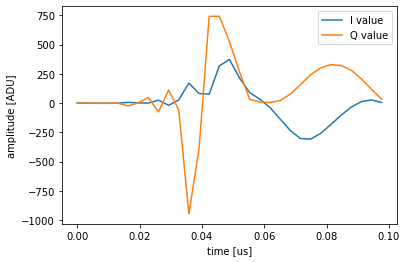

In [5]:
GEN_CH=0 # DAC 
RO_CH=10  # ADC
#BASE WORKABILITY: PLEASE DO NOT CHANGE 
class LoopbackProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        self.declare_gen(ch=gen_ch, nqz=cfg['nqz'], mixer_freq=cfg['mixer_freq'], ro_ch=ro_ch)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro",
                               freq=cfg['freq'],
                               gen_ch=gen_ch,
                               outsel='product')
        self.add_cosine(ch=gen_ch, name="ramp", length=cfg['ramp_len'], even_length=True)
        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch,
                       style="const",
#                        style="flat_top", 
#                        envelope="ramp", 
                       freq=cfg['freq'],
                       length=cfg['flat_len'],
                       phase=cfg['phase'],
                       gain=cfg['gain'],
                      )
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        
        
    def _body(self, cfg):
        self.delay_auto()
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0.0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], mr=True)
        
config = {'gen_ch': GEN_CH,
          'ro_ch': RO_CH,
          'mixer_freq': 100,
          'freq': 10,
          'nqz': 1,
          'trig_time': 0.4,
          'ro_len': .1,
          'flat_len': .2,
          'ramp_len': 0.01,
          'phase': 0,
          'gain': 1.0
         }

prog = LoopbackProgram(soccfg, reps=1, final_delay=0.5, cfg=config)
freq = config['freq']

#external trigger is currently available for tproc_2, on io pin 5, remove start_src if you do not want the trigger
print(prog)
#iq_list = prog.acquire_decimated(soc, progress=True, start_src='external')
iq_list = prog.acquire_decimated(soc, progress=True)

t = prog.get_time_axis(ro_index=0)
iq = iq_list[0]
plt.plot(t, iq[:,0], label="I value")
plt.plot(t, iq[:,1], label="Q value")
plt.legend()
plt.ylabel("amplitude [ADU]")
plt.xlabel("time [us]")

In [ ]:
# attempting to loop a program for several cycles to achieve a continuous signal:
GEN_CH=0 # DAC 
RO_CH=10  # ADC

class LoopbackProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        self.declare_gen(ch=gen_ch, nqz=cfg['nqz'], mixer_freq=cfg['mixer_freq'], ro_ch=ro_ch)
        self.add_cosine(ch=gen_ch, name="ramp", length=cfg['ramp_len'], even_length=True)
        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch,
                       style="const",
#                        style="flat_top", 
#                        envelope="ramp", 
                       freq=cfg['freq'],
                       length=cfg['flat_len'],
                       phase=cfg['phase'],
                       gain=cfg['gain'],
                      )
        self.add_loop("loopedy_loop", 1000000, exec_before=None, exec_after=None)
        
        
    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0.0)
        #self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], mr=True)


        
config = {'gen_ch': GEN_CH,
          'ro_ch': RO_CH,
          'mixer_freq': 100,
          'freq': 100,
          'nqz': 1,
          'trig_time': 0.4,
          'ro_len': .1,
          'flat_len': 1,
          'ramp_len': 0.01,
          'phase': 0,
          'gain': 1.0
         }

prog = LoopbackProgram(soccfg, reps=1, final_delay=0.0, cfg=config)
print(prog)
freq = config['freq']

#external trigger is currently available for tproc_2, on io pin 5, remove start_src if you do not want the trigger
#prog.run(soc, start_src='external', progress=True)
prog.run(soc)
#iq_list = prog.acquire_decimated(soc, progress=False, start_src='external')
# t = prog.get_time_axis(ro_index=0)
# iq = iq_list[0]
# plt.plot(t, iq[:,0], label="I value")
# plt.plot(t, iq[:,1], label="Q value")
# plt.legend()
# plt.ylabel("amplitude [ADU]")
# plt.xlabel("time [us]");

In [ ]:
# attempting to sweep a program for several cycles and achieve a continuous signal:
GEN_CH=0 # DAC 
RO_CH=10  # ADC

class SweepProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        frequency = QickSweep1D("loopedy_loop", 100, 200)    ####HERE
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        self.declare_gen(ch=gen_ch, nqz=cfg['nqz'], mixer_freq=cfg['mixer_freq'], ro_ch=ro_ch)
        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch,
                       style="const",
#                        style="flat_top", 
#                        envelope="ramp", 
                       freq=frequency,                      ###HERE
                       length=cfg['flat_len'],
                       phase=cfg['phase'],
                       gain=cfg['gain'],
                      )
        self.add_loop("loopedy_loop", 100000, exec_before=None, exec_after=None)
        
        
    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t = 0)
        #self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], mr=True)


        
config = {'gen_ch': GEN_CH,
          'ro_ch': RO_CH,
          'mixer_freq': 100,
          'freq': 100,
          'nqz': 1,
          'trig_time': 0.4,
          'ro_len': .1,
          'flat_len': 1,
          'ramp_len': 0.01,
          'phase': 0,
          'gain': 1.0
         }

prog = SweepProgram(soccfg, reps=1, final_delay=0.0, cfg=config)
print(prog)
freq = config['freq']

#external trigger is currently available for tproc_2, on io pin 5, remove start_src if you do not want the trigger
prog.acquire_decimated(soc, progress=True, start_src='external')

In [ ]:
GEN_CH=0 # DAC 
RO_CH=10  # ADC
class LoopbackProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        self.declare_gen(ch=gen_ch, nqz=cfg['nqz'], ro_ch=ro_ch)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro",
                               freq=cfg['adc_freq'],
                               gen_ch=gen_ch,
                               outsel='product')
        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch,
                       style="const",
#                        style="flat_top", 
#                        envelope="ramp", 
                       freq=cfg['dac_freq'],
                       length=cfg['flat_len'],
                       phase=cfg['phase'],
                       gain=cfg['gain'],
                      )
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        
        
    def _body(self, cfg):
        self.delay_auto()
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0.0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['ro_len']+cfg['trig_time']+cfg['down_time'])

        
        
        
config = {'gen_ch': GEN_CH,
          'ro_ch': RO_CH,
          'dac_freq': 120,
          'adc_freq': 110,
          'nqz': 1,
          'trig_time': 0.5,
          'ro_len': 0.004,
          'down_time':0.0059,
          'flat_len': .4,
          'ramp_len': 0.01,
          'phase': 0,
          'gain': 1.0
         }

prog = LoopbackProgram(soccfg, reps=1, final_delay=0.5, cfg=config)


#external trigger is currently available for tproc_2, on io pin 5, remove start_src if you do not want the trigger
exp_pnts = prog.acquire(soc, progress=True)
rounds = prog.get_rounds()
t = prog.get_time_axis(ro_index=0)




In [ ]:
avg_arctan = (np.arctan2(-6, 1) - np.arctan2(-1, 1))/2
arctann = np.arctan2(-1,1)
print(avg_arctan, arctann)
def fast_atan(a, b=1):
    if b == 0:
        return 1.57079633
    else:
        x= a/b
        a = [0.994766756708199, -2.8543851807526100E-01, 0.0760699247645105]
        xx = x * x;
        return ((a[2] * xx + a[1]) * xx + a[0]) * x;


def phase_direction():
    self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
    self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['ro_len']+cfg['trig_time']+cfg['down_time'])
    

In [ ]:
x_coordinates = np.linspace(-math.pi/2, math.pi/2, 500)
fast_arctan = np.zeros(len(x_coordinates))
for i, value in enumerate(x_coordinates):
    fast_arctan[i]=fast_atan(value)
normal_arctan = np.arctan2(x_coordinates, 1)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_coordinates, fast_arctan, label='Fast atan approximation', linestyle='--')
plt.plot(x_coordinates, normal_arctan, label='np.arctan2(x, 1)', linestyle='-')
plt.xlabel('x')
plt.ylabel('arctan value')
plt.title('Comparison of fast atan approximation and numpy arctan2')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

min_val, max_val = -3000, 3000
min_idx_i, max_idx_i = 6000, 0
min_idx_q, max_idx_q = 6000, 0
grid_size = max_val - min_val + 1

In [ ]:
heatmap_data = np.zeros((grid_size, grid_size), dtype=np.float64)
heatmap_data_fast = np.zeros((grid_size, grid_size), dtype=np.float64)
GEN_CH=0 # DAC 
RO_CH=10  # ADC
class LoopbackProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        phase = QickSweep1D("loopedy_loop", 0, 10)    ####HERE

        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        self.declare_gen(ch=gen_ch, nqz=cfg['nqz'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro",
                               freq=cfg['adc_freq'],
                               gen_ch=gen_ch,
                               outsel='product')
        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch,
                       style="const",
#                        style="flat_top", 
#                        envelope="ramp", 
                       freq=cfg['dac_freq'],
                       length=cfg['flat_len'],
                       phase=phase,
                       gain=cfg['gain'],
                      )
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.add_loop("loopedy_loop", 1000, exec_before=None, exec_after=None)



    def _body(self, cfg):
        self.delay_auto()
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0.0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['ro_len']+cfg['trig_time']+cfg['down_time'])




config = {'gen_ch': GEN_CH,
          'ro_ch': RO_CH,
          'dac_freq': 110,
          'adc_freq': 110,
          'nqz': 1,
          'trig_time': 0.5,
          'ro_len': 0.004,
          'down_time':0.0059,
          'flat_len': .4,
          'ramp_len': 0.01,
          'phase': .875,
          'gain': 1.0
         }

prog = LoopbackProgram(soccfg, reps=1, final_delay = 0.1, cfg=config)


#external trigger is currently available for tproc_2, on io pin 5, remove start_src if you do not want the trigger
exp_pnts = prog.acquire(soc, progress = False)
rounds = prog.get_rounds()
t = prog.get_time_axis(ro_index=0)
data = rounds[0][0][0]
x = np.linspace(0,10,len(data))
y = data[:, 0]
z = data[:, 1]
plt.figure()
plt.plot(x, y, label='y data')
plt.title('Trend lines for IQ data')
plt.ylabel('I Values (Arbitrary)')

plt.figure()
plt.plot(x, z)
plt.ylabel('Q Values (Arbitrary)')

plt.figure()
plt.scatter(x[1:], np.diff(np.arctan2(z,y)), s=5)
plt.xlabel('$\phi$ (Arbitrary)')
plt.ylabel('$\Delta\phi (radians)$' )
plt.show()


In [ ]:
valid_points = ~np.isnan(heatmap_data)
y_coords, x_coords = np.where(valid_points)
values = heatmap_data[valid_points]

plt.figure(figsize=(12,10))
scatter = plt.scatter(x_coords-3000, y_coords-3000, c=values, s=50, cmap='viridis')  # s controls size
plt.colorbar(scatter, label='Delta Phase')
plt.gca().invert_yaxis()  # To match imshow orientation if needed
plt.title('Delta Phase Scatter Plot')
plt.xlabel('Delta Q')
plt.ylabel('Delta I')

valid_points = ~np.isnan(heatmap_data_fast)
y_coords, x_coords = np.where(valid_points)
values = heatmap_data_fast[valid_points]

plt.figure(figsize=(12,10))
scatter = plt.scatter(x_coords[values > 0]-3000, y_coords[values > 0]-3000, c=values[values>0], s=50, cmap='viridis')  # s controls size
plt.colorbar(scatter, label='Delta Phase')
plt.gca().invert_yaxis()  # To match imshow orientation if needed
plt.title('Delta Phase Scatter Plot')
plt.xlabel('Delta Q')
plt.ylabel('Delta I')

plt.show()

In [ ]:
valid_points = ~np.isnan(heatmap_data)
y_coords, x_coords = np.where(valid_points)
values = heatmap_data[valid_points]

plt.figure(figsize=(12,10))
scatter = plt.scatter(x_coords-3000, y_coords-3000, c=values, s=2, cmap='viridis')  # s controls size
plt.colorbar(scatter, label='Delta Phase')
plt.gca().invert_yaxis()  # To match imshow orientation if needed
plt.title('Delta Phase Scatter Plot')
plt.xlabel('Delta Q')
plt.ylabel('Delta I')

valid_points = ~np.isnan(heatmap_data_fast)
y_coords, x_coords = np.where(valid_points)
values = heatmap_data_fast[valid_points]

plt.figure(figsize=(12,10))
scatter = plt.scatter(x_coords[values > 0]-3000, y_coords[values > 0]-3000, c=values[values>0], s=2, cmap='viridis')  # s controls size
plt.colorbar(scatter, label='Delta Phase')
plt.gca().invert_yaxis()  # To match imshow orientation if needed
plt.title('Delta Phase Scatter Plot')
plt.xlabel('Delta Q')
plt.ylabel('Delta I')

plt.show()

In [ ]:
# attempting to sweep a program for several cycles and achieve a continuous signal:
GEN_CH=0 # DAC 
RO_CH=10  # ADC

class SweepProgram(AveragerProgramV2):
    def _initialize(self, cfg):

        phase_sweep = QickSweep1D("loopedy_loop", 0, 2*np.pi)    ####HERE

        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        self.declare_gen(ch=gen_ch, nqz=cfg['nqz'], ro_ch=ro_ch)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro",
                               freq=cfg['adc_freq'],
                               gen_ch=gen_ch,
                               outsel='product')
        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch,
                       style="const",
#                        style="flat_top", 
#                        envelope="ramp", 
                       freq=config['dac_freq'],                      ###HERE
                       length=cfg['flat_len'],
                       phase=phase_sweep,
                       gain=cfg['gain'],
                      )
        self.add_pulse(ch=gen_ch, name="warm_up", ro_ch=ro_ch,
                       style="const",
#                        style="flat_top", 
#                        envelope="ramp", 
                       freq=config['dac_freq']+20,                      ###HERE
                       length=cfg['flat_len'],
                       phase=phase_sweep,
                       gain=0.5,
                      )
        self.add_reg("my_reg")
        sub =  AsmV2()
        sub.open_loop(100000, "warm_up")
        sub.pulse(ch=cfg['gen_ch'], name="warm_up", t=0.0)
        sub.close_loop()
        self.add_subroutine("play_warm_up", sub)

        sub =  AsmV2()
        sub.open_loop(500, "loopedy_loop")
        sub.pulse(ch=cfg['gen_ch'], name="mypulse", t=0.0)
        sub.close_loop()
        self.add_subroutine("play_mypulse", sub)

        #self.add_loop("loopedy_loop", 1000, exec_before=None, exec_after=None)
        
        
    def _body(self, cfg):
        self.call("play_warm_up")
        self.call("play_mypulse")
        #for channel 0 the tproc saves it in tproc input 0
        

        
config = {'gen_ch': GEN_CH,
          'ro_ch': RO_CH,
          'dac_freq': 110,
          'adc_freq': 110,
          'nqz': 1,
          'trig_time': 0.5,
          'ro_len': 0.004,
          'down_time':0.0059,
          'flat_len': .04,
          'ramp_len': 0.01,
          'phase': .875,
          'gain': 1.0
         }

prog = SweepProgram(soccfg, reps=1, final_delay=0.0, cfg=config)
print(prog)

#external trigger is currently available for tproc_2, on io pin 5, remove start_src if you do not want the trigger
prog.run(soc)


## This right here reads directly from the registers
##### I will be trying to get it to read phase values instead but it should work with ADC_0.bit

thank you: https://github.com/meeg/qick_demos_sho/blob/main/tprocv2/00_intro.ipynb

In [ ]:

#this line downloads the new hardware (just make sure thats what you want)
#soc = QickSoc()
#soc = QickSoc(bitfile =f'{dir}/tests/d_1.bit', download=True)
#as of Jan 2026: 
#rfsoc_board = most recently published bit, 
# ADC_0 = Self built file that connects adc port 0 to tproc 1
# d_1 = self built that puts a cordic loop on adc port 0 for phase analysis (doesnt work rn)
soc = QickSoc(bitfile =f'{dir}/tests/rf_board_firmware/ADC_0.bit', download=True)
soccfg = soc
#print(soccfg)


  0%|          | 0/1 [00:00<?, ?it/s]

phase offset: 74.4275365412941
buffered readout: [ 3031. 10876.]
feedback readout: [    15147 -61754397]


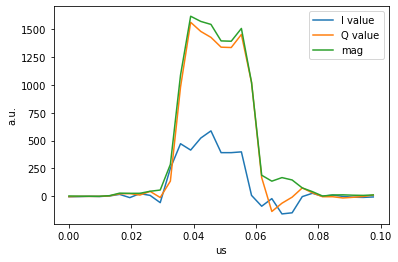

In [189]:
class ReadProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                       style="const", 
                       freq=cfg['freq'], 
                       length=cfg['pulse_len'],
                       phase=cfg['pulse_phase'],
                       gain=cfg['gain'], 
                      )

        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch, phase=cfg['ro_phase'])
        # send the config to the dynamic RO
        self.send_readoutconfig(ch=ro_ch, name="myro", t=0)
        
    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        self.wait_auto(cfg['read_wait'])
        self.read_input(ro_ch=cfg['ro_ch'])
        self.write_dmem(addr=0, src='s_port_l')
        self.write_dmem(addr=1, src='s_port_h')

config = {'gen_ch': 0,
          'ro_ch': 10,
          'freq': 100,
          'trig_time': 0.40,
          'read_wait': 0.1,
          'ro_len': 0.1,
          'pulse_len': 0.025,
          'pulse_phase': 0,
          'ro_phase': 0,
          'gain': 1.0
         }

# prog = ReadProgram(soccfg, reps=100, final_delay=0.5, cfg=config)
# iq_list = prog.acquire(soc, rounds=1, progress=False)
# phase_offset = np.angle(iq_list[0][0].dot([1,1j]), deg=True)
# config['ro_phase'] = -phase_offset

prog = ReadProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

plt.plot(t, iq_list[0][:,0], label="I value")
plt.plot(t, iq_list[0][:,1], label="Q value")
plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="mag")
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");

phase_offset = np.angle(iq_list[0].sum(axis=0).dot([1,1j]), deg=True)
print("phase offset:", phase_offset)

print("buffered readout:", iq_list[0].sum(axis=0))
print("feedback readout:", soc.read_mem(2,'dmem'))

#### OK OK OK MY HADWARE DOESNT CRASH
##### lets see if its looking at phase or not

In [7]:

soc = QickSoc(bitfile =f'{dir}/tests/rf_board_firmware/d_1.bit', download=True)
soccfg = soc
print(soccfg)


QICK running on ZCU216, software version 0.2.388

Firmware configuration (built Fri Apr  3 16:28:09 2026):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc core clock, tProc timing clock, DAC tile 1, DAC tile 2, DAC tile 3], [DAC tile 0], [ADC tile 1, ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 65536 complex samples (6.838 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 0 is 0_228 on JHC1, or QICK box DAC port 0
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 1 is 1_228 on JHC2, or QICK box DAC port 1
	2:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 32768 complex samples (3.419 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 2 is 2_228 on JHC1, or QICK box DAC port 2
	3:	axis_signal_ge

In [197]:
def phase_change(freq_range=(100,110), freq_division = 10, num_reps = 10):
    class ReadProgram(AveragerProgramV2):
        def _initialize(self, cfg):
            ro_ch = cfg['ro_ch']
            gen_ch = cfg['gen_ch']
            
            self.declare_gen(ch=gen_ch, nqz=1)
            self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

            self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                        style="const", 
                        freq=cfg['freq'], 
                        length=cfg['pulse_len'],
                        phase=cfg['pulse_phase'],
                        gain=cfg['gain'], 
                        )

            self.add_readoutconfig(ch=ro_ch, name="myro", freq=config['freq'], gen_ch=gen_ch, phase=cfg['ro_phase'])
            # send the config to the dynamic RO
            self.send_readoutconfig(ch=ro_ch, name="myro", t=0)
            
        def _body(self, cfg):
            self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
            self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
            self.wait_auto(cfg['read_wait'])
            self.read_input(ro_ch=cfg['ro_ch'])
            self.write_dmem(addr=0, src='s_port_l')
            self.write_dmem(addr=1, src='s_port_h')

    

    # prog = ReadProgram(soccfg, reps=100, final_delay=0.5, cfg=config)
    # iq_list = prog.acquire(soc, rounds=1, progress=False)
    # phase_offset = np.angle(iq_list[0][0].dot([1,1j]), deg=True)
    # config['ro_phase'] = -phase_offset
    plt.figure()
    freq_span = np.linspace(freq_range[0], freq_range[1], freq_division)
    phasebyfreq = []
    for i, freq in enumerate(freq_span):
        config = {'gen_ch': 0,
            'ro_ch': 10,
            'freq': freq,
            'trig_time': 0.40,
            'read_wait': 0.1,
            'ro_len': 0.1,
            'pulse_len': 0.025,
            'pulse_phase':0,
            'ro_phase': 0,
            'gain': 0.5
            }
        freq_data = []
        for rep in range(num_reps):
            prog = ReadProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

            iq_list = prog.acquire_decimated(soc, progress = False, rounds=1)
            t = prog.get_time_axis(ro_index=0)

            phase_maybe = soc.read_mem(2,'dmem')
            
            mag = int(phase_maybe[0])/(2**14-1)
            phase_dif = int(phase_maybe[1])/(2**32-1)

            freq_data.append((phase_dif, mag))
            
        phasebyfreq.append(freq_data)
    return phasebyfreq
freq_range = (109.5,110.5)
freq_division = 21
phasebyfreq = phase_change(freq_range=freq_range, freq_division= 21, num_reps=300)

<Figure size 432x288 with 0 Axes>

-0.00634420034623337


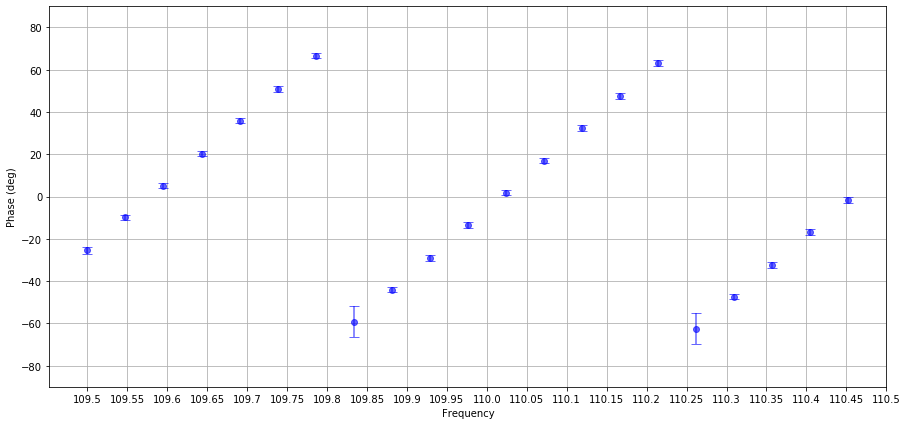

In [184]:

plt.figure(figsize = (15,7))

# Assuming phasebyfreq is a list of arrays or lists, each with shape (N, 2)
print(phasebyfreq[0][0][0])
for idx, phase_vals in enumerate(phasebyfreq):

    phase_vals = np.asarray(phase_vals)
    value = phase_vals[:, 0]*180

    mean_val = np.mean(value)
    std_val = np.std(value)

    # Plot mean with error bar (std deviation)
    plt.errorbar(idx, mean_val, yerr=std_val, fmt='o', alpha=0.6, capsize=5, color='blue')

# Set x-ticks to correspond to frequencies
freqs = np.linspace(freq_range[0], freq_range[1], len(phasebyfreq))
plt.xticks(np.linspace(0,21,21), freqs)
plt.ylim(-90,90)
plt.ylabel("Phase (deg)")
plt.xlabel("Frequency")
plt.grid(True)
#plt.title("Phase Error by Frequency")


-0.14721496220380417


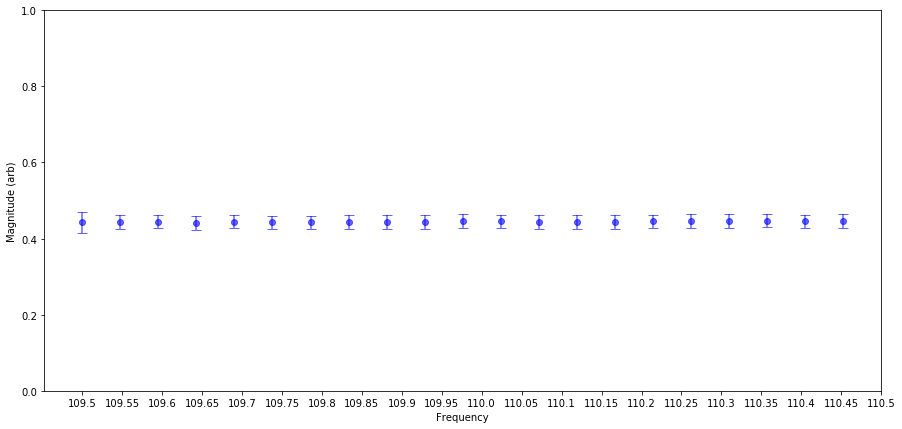

In [ ]:

plt.figure(figsize = (15,7))

# Assuming phasebyfreq is a list of arrays or lists, each with shape (N, 2)
print(phasebyfreq[0][1][0])
for idx, phase_vals in enumerate(phasebyfreq):

    phase_vals = np.asarray(phase_vals)
    value = phase_vals[:, 1]

    mean_val = np.mean(value)
    std_val = np.std(value)

    # Plot mean with error bar (std deviation)
    plt.errorbar(idx, mean_val, yerr=std_val, fmt='o', alpha=0.6, capsize=5, color='blue')

# Set x-ticks to correspond to frequencies
freqs = np.linspace(freq_range[0], freq_range[1], len(phasebyfreq))
plt.xticks(np.linspace(0,21,21), freqs)
plt.ylabel("Magnitude (arb)")
plt.xlabel("Frequency")
#plt.title("Magnitude error by Frequency")
plt.ylim(0,1)

plt.show()

In [190]:

plt.figure()
one_val = phasebyfreq[0]
plt.scatter(one_val[:,1],one_val[:,0], alpha = 0.3)

plt.ylim(0, 4e-7)

TypeError: list indices must be integers or slices, not tuple

<Figure size 432x288 with 0 Axes>

### Its seeing phase and magnitude perfectly We have achieved Phase on the Fly!!

  0%|          | 0/1 [00:00<?, ?it/s]

phase offset: -0.520265196604034
buffered readout: [11453.  -104.]
mag 11453.472180958925
feedback readout: [  13302 2206717]
difference: 1848.5278190410754
dmem phase: 0.18496488229602803


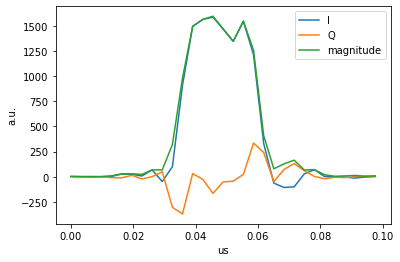

In [111]:
class ReadProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                       style="const", 
                       freq=cfg['freq'], 
                       length=cfg['pulse_len'],
                       phase=cfg['pulse_phase'],
                       gain=cfg['gain'], 
                      )

        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch, phase=cfg['ro_phase'])
        # send the config to the dynamic RO
        self.send_readoutconfig(ch=ro_ch, name="myro", t=0)
        
    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        self.wait_auto(cfg['read_wait'])
        self.read_input(ro_ch=cfg['ro_ch'])
        self.write_dmem(addr=0, src='s_port_l')
        self.write_dmem(addr=1, src='s_port_h')

config = {'gen_ch': 0,
          'ro_ch': 10,
          'freq': 100,
          'trig_time': 0.40,
          'read_wait': 0.1,
          'ro_len': 0.1,
          'pulse_len': 0.025,
          'pulse_phase': 0,
          'ro_phase': -74.1,
          'gain': 1.0
         }

# prog = ReadProgram(soccfg, reps=100, final_delay=0.5, cfg=config)
# iq_list = prog.acquire(soc, rounds=1, progress=False)
# phase_offset = np.angle(iq_list[0][0].dot([1,1j]), deg=True)
# config['ro_phase'] = -phase_offset

prog = ReadProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

plt.plot(t, iq_list[0][:,0], label="I")
plt.plot(t, iq_list[0][:,1], label="Q")
plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="magnitude")
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");

phase_offset = np.angle(iq_list[0].sum(axis=0).dot([1,1j]), deg=True)
print("phase offset:", phase_offset)
buffered_readout = iq_list[0].sum(axis=0)
magnitude = np.abs(buffered_readout.dot([1,1j]))
print("buffered readout:", iq_list[0].sum(axis=0))
print("mag", magnitude)
print("feedback readout:", soc.read_mem(2,'dmem'))
print("difference:", np.abs(soc.read_mem(2,'dmem')[0]-(magnitude)))

print("dmem phase:", (soc.read_mem(2,'dmem')[1]/(2**31-1))*180)